In [1]:
import torch
import re, subprocess
import gc, re, os, hashlib
import numpy as np
import wandb
from scipy.special import softmax
from jax.tree_util import tree_map
from esmfold import ESMFold
import os, tarfile, urllib.request
import math
import matplotlib.pyplot as plt

In [2]:
OUT_DIR = "casp14_targets"
NUM_RECYCLES = 3 #["0", "1", "2", "3", "6", "12", "24"]
CHAIN_LINKER = 25

os.makedirs(OUT_DIR, exist_ok=True)

In [3]:
## DOWNLOAD CASP14 DATASET
url = "https://predictioncenter.org/download_area/CASP14/targets/casp14.targets.T.public_11.29.2020.tar.gz"

tgz_path = os.path.join(OUT_DIR, os.path.basename(url))
if not os.path.exists(tgz_path):
    urllib.request.urlretrieve(url, tgz_path)

with tarfile.open(tgz_path, "r:gz") as tf:
    tf.extractall(OUT_DIR)

print("Extracted to:", OUT_DIR)

Extracted to: casp14_targets


/tmp/ipykernel_12974/1711440372.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(OUT_DIR)


In [4]:
from pathlib import Path

def read_fasta_to_dict(path):
    seqs = {}
    pdbs = {}
    name = None
    seq_chunks = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if name is not None and os.path.isfile(os.path.join(OUT_DIR, name + ".pdb")):
                    seqs[name] = "".join(seq_chunks)
                    pdbs[name] = os.path.join(OUT_DIR, name + ".pdb")
                name = line[1:].split()[0]   # e.g. T1024
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if name is not None and os.path.isfile(os.path.join(OUT_DIR, name + ".pdb")):
            seqs[name] = "".join(seq_chunks)
            pdbs[name] = os.path.join(OUT_DIR, name + ".pdb")
            
    return seqs, pdbs

def compute_tm_score(pred_pdb, target_pdb, exe="./TMalign"):
    out = subprocess.check_output([exe, pred_pdb, target_pdb], text=True)
    m = re.search(r"TM-score\s*=\s*([0-9.]+)", out)
    if not m:
        raise RuntimeError("TM-score not found in TM-align output:\n" + out[:1000])
    return float(m.group(1))

In [5]:
## FOR OUTPUT VISUALIZATION

def parse_output(output):
    pae = (output["aligned_confidence_probs"][0] * np.arange(64)).mean(-1) * 31
    plddt = output["plddt"][0,:,1]
    
    bins = np.append(0,np.linspace(2.3125,21.6875,63))
    sm_contacts = softmax(output["distogram_logits"],-1)[0]
    sm_contacts = sm_contacts[...,bins<8].sum(-1)
    xyz = output["positions"][-1,0,:,1]
    mask = output["atom37_atom_exists"][0,:,1] == 1
    o = {"pae":pae[mask,:][:,mask],
         "plddt":plddt[mask],
         "sm_contacts":sm_contacts[mask,:][:,mask],
         "xyz":xyz[mask]}
    return o

In [6]:
## GARBAGE COLLECTION

gc.collect()
torch.cuda.empty_cache()

In [7]:
## LOAD MODEL AND TRANSFER WEIGHTS
pretrained = torch.load("esmfold.model", weights_only=False)
model = ESMFold(esmfold_config=pretrained.cfg) ## make copy of model with new forward pass and then transfer the weights
model.load_state_dict(pretrained.state_dict())
model = torch.compile(
    model,
    mode="reduce-overhead", 
)
model.eval().cuda().requires_grad_(False)

del pretrained
gc.collect()
torch.cuda.empty_cache()

chunk_size = 128
model.set_chunk_size(chunk_size)

In [8]:
## LOAD DATASET 
seqs, pdbs = read_fasta_to_dict("casp14_seq.txt")

In [24]:
model.profiler.timings

{'input_prep': [0.8017280101776123],
 'esm2_encoding': [71.03401947021484],
 'esm_preprocessing': [0.8910719752311707],
 'recycle_norm_s': [0.13625599443912506,
  0.15744000673294067,
  0.13974399864673615,
  0.14035199582576752],
 'recycle_norm_z': [0.159743994474411,
  0.18211199343204498,
  0.19049599766731262,
  0.17004799842834473],
 'recycle_disto_embed': [0.17587199807167053,
  0.19622400403022766,
  0.20121599733829498,
  0.19468800723552704],
 'pairwise_positional_embedding': [0.7825599908828735,
  0.45635199546813965,
  0.47775998711586,
  0.4792320132255554],
 'bias_pair_to_sequence': [0.2441920042037964,
  0.21660800278186798,
  0.2091200053691864,
  0.20742399990558624,
  0.21481600403785706,
  0.2070399969816208,
  0.23523199558258057,
  0.20819200575351715,
  0.21055999398231506,
  0.22191999852657318,
  0.21132799983024597,
  0.20665599405765533,
  0.23980799317359924,
  0.22889600694179535,
  0.2314240038394928,
  0.21132799983024597,
  0.20796799659729004,
  0.2071039

In [9]:
def predict(sequence):
    def get_hash(x): return hashlib.sha1(x.encode()).hexdigest()
    ID ="test_"+get_hash(sequence)[:5]

    # Ensure profiler is clean before starting
    model.profiler.reset()

    wandb.init(
        project="esmfold-experiments",
        name=f"compile-{ID}",
        settings=wandb.Settings(silent=True),
        group="compile-casp14",
        config={
            "sequence": sequence,
            "num_recycles": NUM_RECYCLES,
            "chunk_size": chunk_size,
            "length": len(sequence),
        }
    )

    output_gpu = model.infer(sequence,
                             num_recycles=NUM_RECYCLES,
                             residue_index_offset=512)

    # Get full summary with detailed metrics
    summary = model.profiler.summary()

    # Get total forward time from timings dict
    total_time = model.profiler.timings.get("total_forward", [0])[0]

    # Add percentages to summary
    if "groups" in summary and summary["groups"]:
        for group_name, metrics in summary["groups"].items():
            percent = 100.0 * metrics["total_time_ms"] / total_time if total_time > 0 else 0.0
            summary["groups"][group_name]["percent"] = percent

    # Organize wandb logging
    wandb_metrics = {}

    # Log group-level metrics
    if "groups" in summary:
        for group_name, metrics in summary["groups"].items():
            wandb_metrics[f"groups/{group_name}/percent"] = metrics.get("percent", 0.0)
            wandb_metrics[f"groups/{group_name}/cpu_time_ms"] = metrics.get("cpu_time_ms", 0.0)
            wandb_metrics[f"groups/{group_name}/cuda_time_ms"] = metrics.get("cuda_time_ms", 0.0)
            wandb_metrics[f"groups/{group_name}/total_time_ms"] = metrics.get("total_time_ms", 0.0)
            wandb_metrics[f"groups/{group_name}/memory_mb"] = metrics.get("memory_mb", 0.0)
            wandb_metrics[f"groups/{group_name}/memory_delta_mb"] = metrics.get("memory_delta_mb", 0.0)

    # Log section-level metrics
    if "sections" in summary:
        for section_name, metrics in summary["sections"].items():
            wandb_metrics[f"sections/{section_name}/cpu_time_ms"] = metrics.get("cpu_time_ms", 0.0)
            wandb_metrics[f"sections/{section_name}/cuda_time_ms"] = metrics.get("cuda_time_ms", 0.0)
            wandb_metrics[f"sections/{section_name}/total_time_ms"] = metrics.get("total_time_ms", 0.0)
            wandb_metrics[f"sections/{section_name}/memory_mb"] = metrics.get("memory_mb", 0.0)
            wandb_metrics[f"sections/{section_name}/memory_delta_mb"] = metrics.get("memory_delta_mb", 0.0)

    # Log total forward time
    wandb_metrics["total_forward_time_ms"] = total_time

    # Single wandb.log call with all metrics
    wandb.log(wandb_metrics)

    wandb.finish()

    pdb_str = model.output_to_pdb(output_gpu)[0]

    output = tree_map(lambda x: x.cpu().numpy(), output_gpu)
    del output_gpu
    torch.cuda.empty_cache()
    gc.collect()

    ptm = output["ptm"][0]
    plddt = output["plddt"][0,...,1].mean()
    O = parse_output(output)

    os.system(f"mkdir -p {ID}")
    prefix = f"{ID}/ptm{ptm:.3f}_r{NUM_RECYCLES}_default"
    np.savetxt(f"{prefix}.pae.txt",O["pae"],"%.3f")
    with open(f"{prefix}.pdb","w") as out:
        out.write(pdb_str)

    del output, pdb_str, O
    gc.collect()
    torch.cuda.empty_cache()

    return ptm, plddt, summary, f"{prefix}.pdb", total_time

In [10]:
GROUPS = ["INPUT_EMBEDDING","BIAS_AND_MLP","TRIANGULAR_MULTIPLICATION","TRIANGULAR_ATTENTION","STRUCTURE_MODULE"]

rows = []
for k,seq in seqs.items():
    if len(seq) < 2000:
        ptm, plddt, summary, pred_pdb, total_time = predict(seq)
        tm = compute_tm_score(pred_pdb, pdbs[k])
        
        # Extract group metrics from summary
        groups = summary.get("groups", {})
        group_data = {}
        for g in GROUPS:
            if g in groups:
                group_data[g] = {
                    "percent": groups[g].get("percent", math.nan),
                    "cpu_time_ms": groups[g].get("cpu_time_ms", math.nan),
                    "cuda_time_ms": groups[g].get("cuda_time_ms", math.nan),
                    "total_time_ms": groups[g].get("total_time_ms", math.nan),
                    "memory_mb": groups[g].get("memory_mb", math.nan),
                    "memory_delta_mb": groups[g].get("memory_delta_mb", math.nan),
                }
            else:
                group_data[g] = {
                    "percent": math.nan,
                    "cpu_time_ms": math.nan,
                    "cuda_time_ms": math.nan,
                    "total_time_ms": math.nan,
                    "memory_mb": math.nan,
                    "memory_delta_mb": math.nan,
                }
        
        rows.append((k, len(seq), ptm, plddt, tm, total_time, group_data))
        print(k)
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

# Print results table
pct = lambda v: f"{v:.2f}%" if v==v else "nan"
wk = max(len("k"),   *(len(str(r[0])) for r in rows))
wl = max(len("len"), *(len(str(r[1])) for r in rows))
wg = [max(len(g), *(len(pct(r[6][g]["percent"])) for r in rows)) for g in GROUPS]
hdr = f"{'k':<{wk}}  {'len':>{wl}}  {'ptm':>7}  {'plddt':>8}  {'tm':>8}  {'tt':>8}  " + "  ".join(f"{g:>{w}}" for g,w in zip(GROUPS,wg))
print(hdr)
for k,L,ptm,plddt,tm,tt,group_data in rows:
    print(f"{k:<{wk}}  {L:>{wl}}  {ptm:7.4f}  {plddt:8.4f}  {tm:8.4f}  {tt:8.3f}  " +
          "  ".join(f"{pct(group_data[g]['percent']):>{w}}" for g,w in zip(GROUPS,wg)))

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


T1024
T1025
T1026
T1027
T1029
T1030
T1031
T1032
T1033
T1035
T1036s1
T1037
T1038
T1039
T1040
T1041
T1042
T1043
T1046s1
T1046s2
T1049
T1050
T1054
T1056
T1064
T1067
T1073
T1074
T1079
T1080
T1082
T1090
T1099
k        len      ptm     plddt        tm        tt  INPUT_EMBEDDING  BIAS_AND_MLP  TRIANGULAR_MULTIPLICATION  TRIANGULAR_ATTENTION  STRUCTURE_MODULE
T1024    408   0.9530   94.3247    0.9114  6476.009            5.05%         7.77%                     24.76%                50.84%            11.25%
T1025    268   0.9388   93.5263    0.9118  4053.107            1.76%         9.89%                     16.75%                37.96%            15.94%
T1026    172   0.6769   73.1035    0.8091  3674.967            2.04%         8.68%                     15.92%                32.09%            17.80%
T1027    168   0.3962   47.2241    0.5196  3507.001            2.13%         8.87%                     16.40%                33.91%            18.70%
T1029    125   0.3544   45.4685    0.4988  316

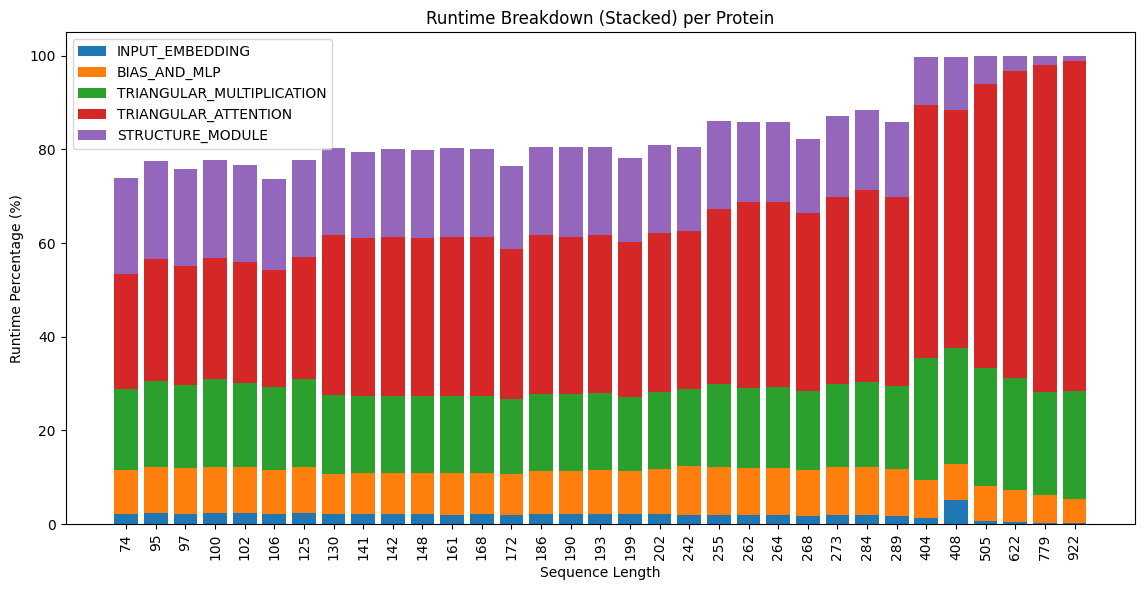

In [11]:
# Sort by sequence length so the bars are in increasing L
rows_sorted = sorted(rows, key=lambda r: r[1])
ks      = [r[0] for r in rows_sorted]
lengths = [r[1] for r in rows_sorted]

# Build group->values (percent) aligned to rows_sorted
group_vals = {g: [] for g in GROUPS}
for r in rows_sorted:
    group_data = r[6]  # dict of group metrics
    for g in GROUPS:
        pct_val = group_data[g]["percent"]
        group_vals[g].append(0.0 if (pct_val != pct_val) else float(pct_val))  # NaN -> 0 for stacking

x = np.arange(len(rows_sorted))

plt.figure(figsize=(max(10, 0.35 * len(rows_sorted)), 6))

bottom = np.zeros(len(rows_sorted), dtype=float)
for g in GROUPS:
    y = np.array(group_vals[g], dtype=float)
    plt.bar(x, y, bottom=bottom, label=g)
    bottom += y

plt.ylabel("Runtime Percentage (%)")
plt.title("Runtime Breakdown (Stacked) per Protein")
plt.xticks(x, [str(L) for L in lengths], rotation=90)  # show lengths on x-axis
plt.xlabel("Sequence Length")
plt.legend()
plt.tight_layout()
plt.show()

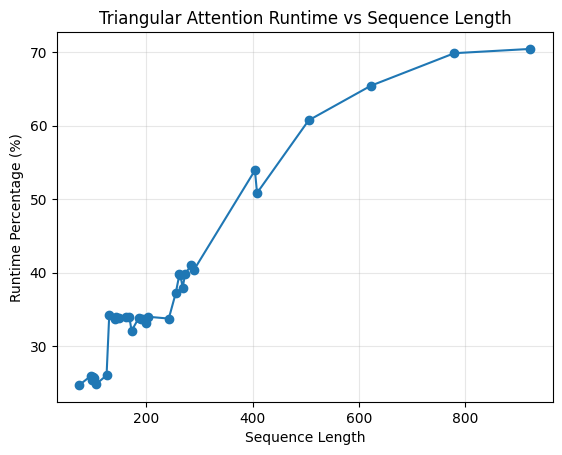

In [12]:
# Sort by sequence length
rows_sorted = sorted(rows, key=lambda r: r[1])

lengths = []
tri_attn_pct = []

for _, L, _, _, _, _, group_data in rows_sorted:
    v = group_data["TRIANGULAR_ATTENTION"]["percent"]
    if v == v:  # skip NaNs
        lengths.append(L)
        tri_attn_pct.append(v)

plt.figure()
plt.plot(lengths, tri_attn_pct, marker="o")

plt.xlabel("Sequence Length")
plt.ylabel("Runtime Percentage (%)")
plt.title("Triangular Attention Runtime vs Sequence Length")
plt.grid(True, alpha=0.3)
plt.show()

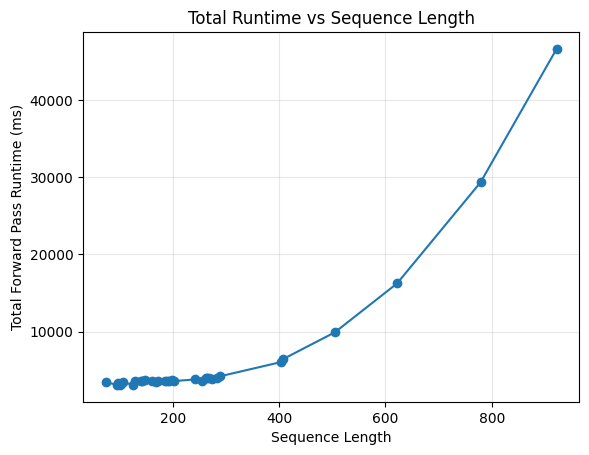

In [13]:
rows_sorted = sorted(rows, key=lambda r: r[1])

lengths = [r[1] for r in rows_sorted]
total_times = [r[5] for r in rows_sorted]

plt.figure()
plt.plot(lengths, total_times, marker="o")

plt.xlabel("Sequence Length")
plt.ylabel("Total Forward Pass Runtime (ms)")
plt.title("Total Runtime vs Sequence Length")
plt.grid(True, alpha=0.3)
plt.show()

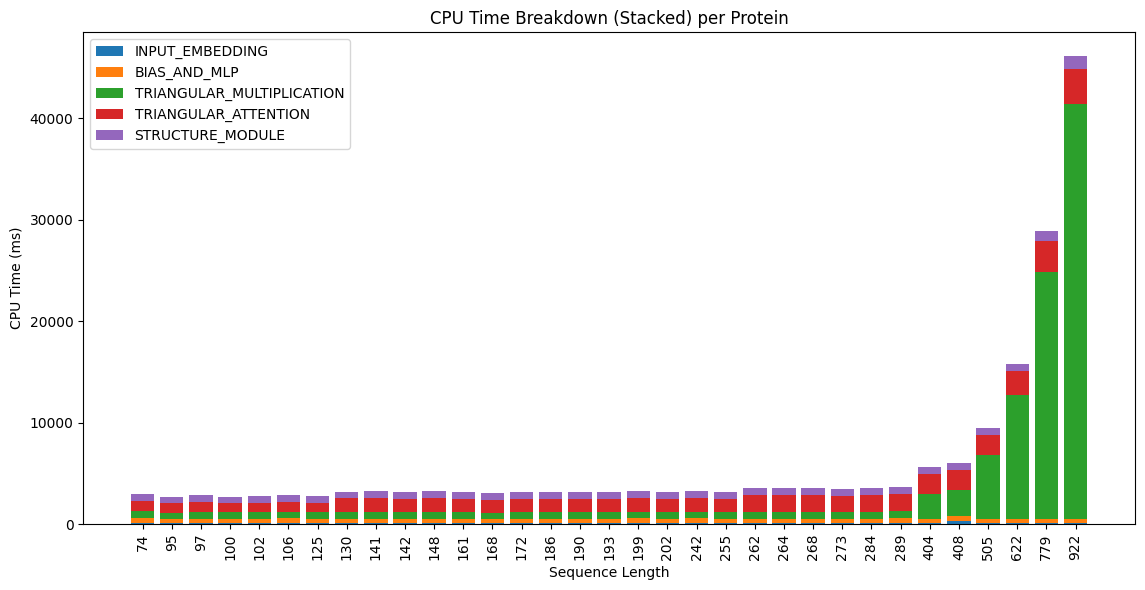

In [14]:
# CPU Time per Group - Stacked Bar Chart
rows_sorted = sorted(rows, key=lambda r: r[1])
lengths = [r[1] for r in rows_sorted]

group_cpu_vals = {g: [] for g in GROUPS}
for r in rows_sorted:
    group_data = r[6]
    for g in GROUPS:
        cpu_val = group_data[g]["cpu_time_ms"]
        group_cpu_vals[g].append(0.0 if (cpu_val != cpu_val) else float(cpu_val))

x = np.arange(len(rows_sorted))

plt.figure(figsize=(max(10, 0.35 * len(rows_sorted)), 6))

bottom = np.zeros(len(rows_sorted), dtype=float)
for g in GROUPS:
    y = np.array(group_cpu_vals[g], dtype=float)
    plt.bar(x, y, bottom=bottom, label=g)
    bottom += y

plt.ylabel("CPU Time (ms)")
plt.title("CPU Time Breakdown (Stacked) per Protein")
plt.xticks(x, [str(L) for L in lengths], rotation=90)
plt.xlabel("Sequence Length")
plt.legend()
plt.tight_layout()
plt.show()

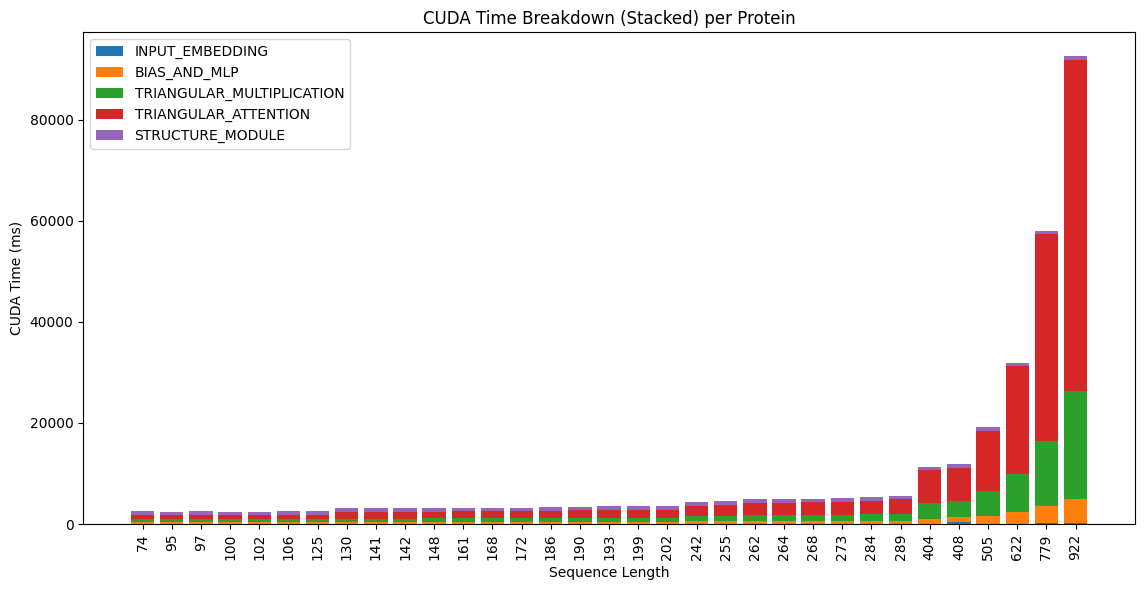

In [15]:
# CUDA Time per Group - Stacked Bar Chart
rows_sorted = sorted(rows, key=lambda r: r[1])
lengths = [r[1] for r in rows_sorted]

group_cuda_vals = {g: [] for g in GROUPS}
for r in rows_sorted:
    group_data = r[6]
    for g in GROUPS:
        cuda_val = group_data[g]["cuda_time_ms"]
        group_cuda_vals[g].append(0.0 if (cuda_val != cuda_val) else float(cuda_val))

x = np.arange(len(rows_sorted))

plt.figure(figsize=(max(10, 0.35 * len(rows_sorted)), 6))

bottom = np.zeros(len(rows_sorted), dtype=float)
for g in GROUPS:
    y = np.array(group_cuda_vals[g], dtype=float)
    plt.bar(x, y, bottom=bottom, label=g)
    bottom += y

plt.ylabel("CUDA Time (ms)")
plt.title("CUDA Time Breakdown (Stacked) per Protein")
plt.xticks(x, [str(L) for L in lengths], rotation=90)
plt.xlabel("Sequence Length")
plt.legend()
plt.tight_layout()
plt.show()

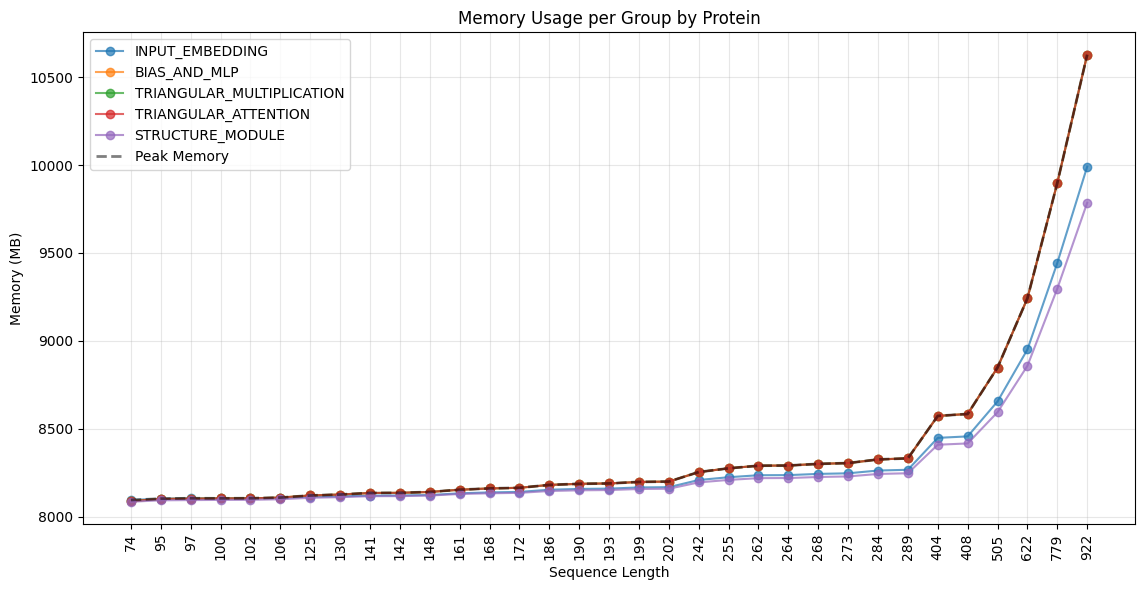

In [16]:
# Memory Usage per Group - Stacked Bar Chart
rows_sorted = sorted(rows, key=lambda r: r[1])
lengths = [r[1] for r in rows_sorted]

group_memory_vals = {g: [] for g in GROUPS}
for r in rows_sorted:
    group_data = r[6]
    for g in GROUPS:
        memory_val = group_data[g]["memory_mb"]
        group_memory_vals[g].append(0.0 if (memory_val != memory_val) else float(memory_val))

x = np.arange(len(rows_sorted))

plt.figure(figsize=(max(10, 0.35 * len(rows_sorted)), 6))

# For memory, we take the max across groups since they can overlap
max_memory = np.zeros(len(rows_sorted), dtype=float)
for g in GROUPS:
    y = np.array(group_memory_vals[g], dtype=float)
    max_memory = np.maximum(max_memory, y)

# Plot individual groups
for g in GROUPS:
    y = np.array(group_memory_vals[g], dtype=float)
    plt.plot(x, y, marker='o', label=g, alpha=0.7)

# Plot max memory line
plt.plot(x, max_memory, 'k--', linewidth=2, label='Peak Memory', alpha=0.5)

plt.ylabel("Memory (MB)")
plt.title("Memory Usage per Group by Protein")
plt.xticks(x, [str(L) for L in lengths], rotation=90)
plt.xlabel("Sequence Length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

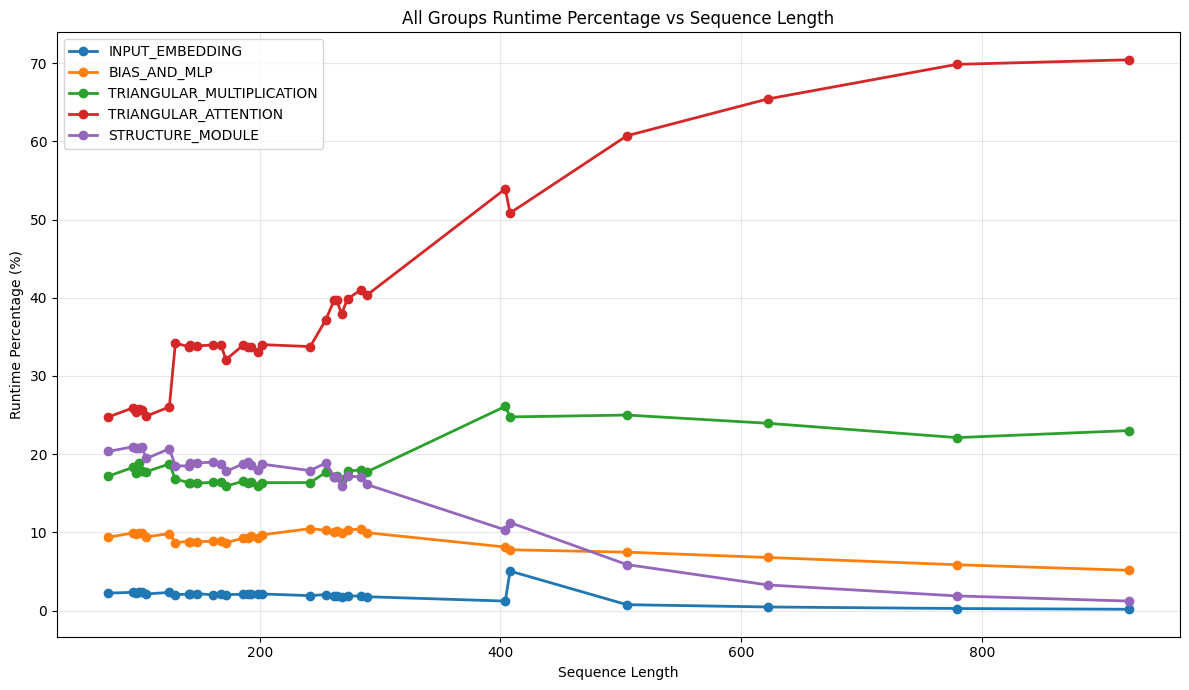

In [17]:
# All Groups Runtime Percentage vs Sequence Length
rows_sorted = sorted(rows, key=lambda r: r[1])

plt.figure(figsize=(12, 7))

for g in GROUPS:
    lengths = []
    percents = []
    
    for _, L, _, _, _, _, group_data in rows_sorted:
        v = group_data[g]["percent"]
        if v == v:  # skip NaNs
            lengths.append(L)
            percents.append(v)
    
    if lengths:  # only plot if we have data
        plt.plot(lengths, percents, marker="o", label=g, linewidth=2)

plt.xlabel("Sequence Length")
plt.ylabel("Runtime Percentage (%)")
plt.title("All Groups Runtime Percentage vs Sequence Length")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

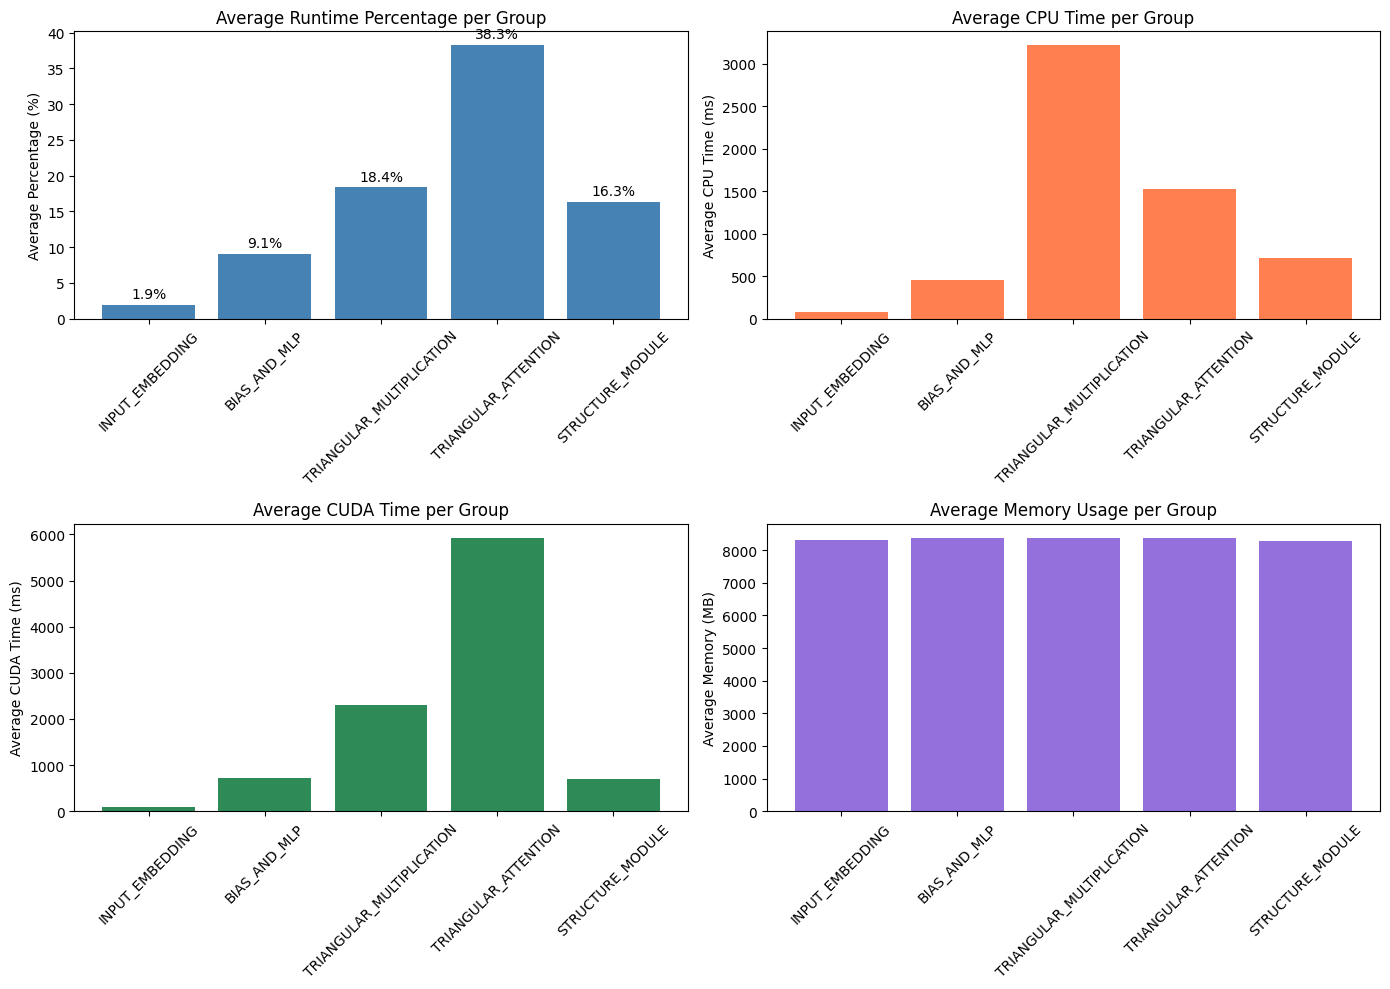

In [18]:
# Average Metrics Per Group (across all proteins)
avg_metrics = {g: {"percent": [], "cpu_time_ms": [], "cuda_time_ms": [], "total_time_ms": [], "memory_mb": []} for g in GROUPS}

for r in rows:
    group_data = r[6]
    for g in GROUPS:
        for metric in ["percent", "cpu_time_ms", "cuda_time_ms", "total_time_ms", "memory_mb"]:
            val = group_data[g][metric]
            if val == val:  # skip NaNs
                avg_metrics[g][metric].append(val)

# Calculate averages
avg_results = {}
for g in GROUPS:
    avg_results[g] = {
        "percent": np.mean(avg_metrics[g]["percent"]) if avg_metrics[g]["percent"] else 0,
        "cpu_time_ms": np.mean(avg_metrics[g]["cpu_time_ms"]) if avg_metrics[g]["cpu_time_ms"] else 0,
        "cuda_time_ms": np.mean(avg_metrics[g]["cuda_time_ms"]) if avg_metrics[g]["cuda_time_ms"] else 0,
        "total_time_ms": np.mean(avg_metrics[g]["total_time_ms"]) if avg_metrics[g]["total_time_ms"] else 0,
        "memory_mb": np.mean(avg_metrics[g]["memory_mb"]) if avg_metrics[g]["memory_mb"] else 0,
    }

# Create subplots for different metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Average Runtime Percentage
ax1 = axes[0, 0]
percents = [avg_results[g]["percent"] for g in GROUPS]
ax1.bar(GROUPS, percents, color='steelblue')
ax1.set_ylabel("Average Percentage (%)")
ax1.set_title("Average Runtime Percentage per Group")
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(percents):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom')

# Plot 2: Average CPU Time
ax2 = axes[0, 1]
cpu_times = [avg_results[g]["cpu_time_ms"] for g in GROUPS]
ax2.bar(GROUPS, cpu_times, color='coral')
ax2.set_ylabel("Average CPU Time (ms)")
ax2.set_title("Average CPU Time per Group")
ax2.tick_params(axis='x', rotation=45)

# Plot 3: Average CUDA Time
ax3 = axes[1, 0]
cuda_times = [avg_results[g]["cuda_time_ms"] for g in GROUPS]
ax3.bar(GROUPS, cuda_times, color='seagreen')
ax3.set_ylabel("Average CUDA Time (ms)")
ax3.set_title("Average CUDA Time per Group")
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Average Memory Usage
ax4 = axes[1, 1]
memory_usage = [avg_results[g]["memory_mb"] for g in GROUPS]
ax4.bar(GROUPS, memory_usage, color='mediumpurple')
ax4.set_ylabel("Average Memory (MB)")
ax4.set_title("Average Memory Usage per Group")
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

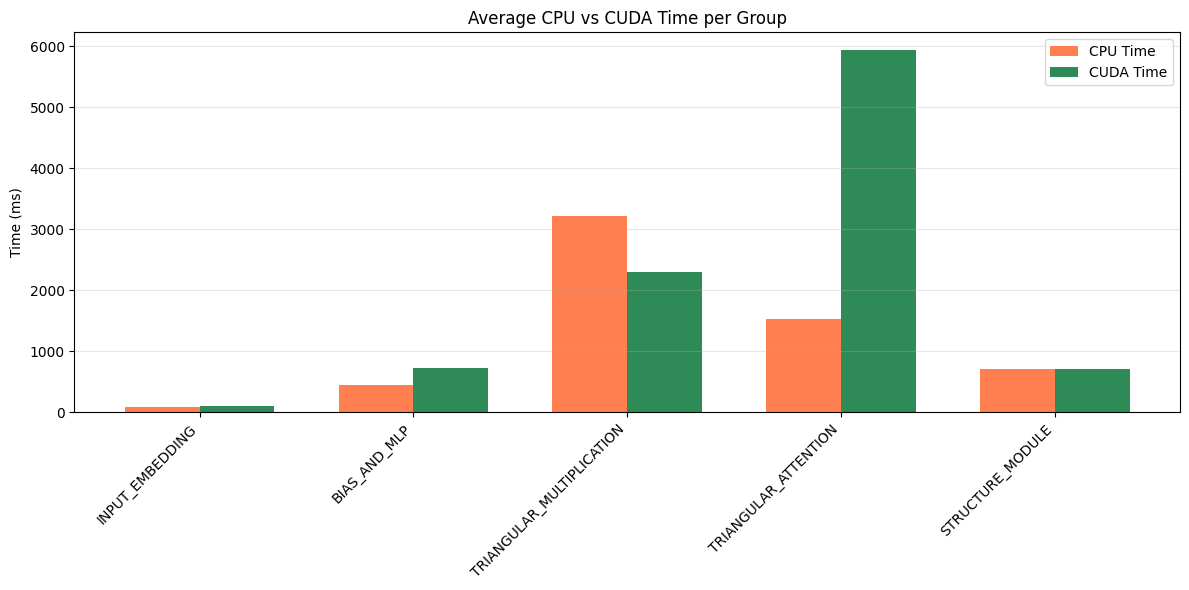

In [19]:
# CPU vs CUDA Time Comparison per Group
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(GROUPS))
width = 0.35

cpu_times = [avg_results[g]["cpu_time_ms"] for g in GROUPS]
cuda_times = [avg_results[g]["cuda_time_ms"] for g in GROUPS]

bars1 = ax.bar(x - width/2, cpu_times, width, label='CPU Time', color='coral')
bars2 = ax.bar(x + width/2, cuda_times, width, label='CUDA Time', color='seagreen')

ax.set_ylabel('Time (ms)')
ax.set_title('Average CPU vs CUDA Time per Group')
ax.set_xticks(x)
ax.set_xticklabels(GROUPS, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

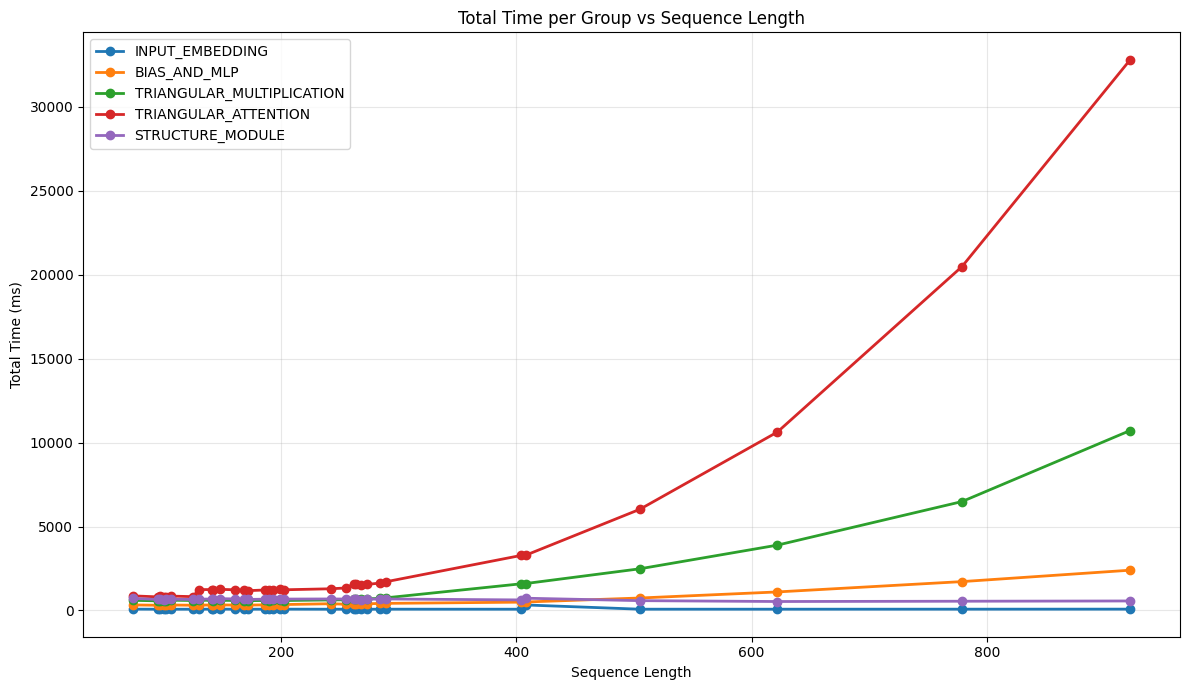

In [20]:
# Total Time per Group vs Sequence Length
rows_sorted = sorted(rows, key=lambda r: r[1])

plt.figure(figsize=(12, 7))

for g in GROUPS:
    lengths = []
    times = []
    
    for _, L, _, _, _, _, group_data in rows_sorted:
        v = group_data[g]["total_time_ms"]
        if v == v:  # skip NaNs
            lengths.append(L)
            times.append(v)
    
    if lengths:  # only plot if we have data
        plt.plot(lengths, times, marker="o", label=g, linewidth=2)

plt.xlabel("Sequence Length")
plt.ylabel("Total Time (ms)")
plt.title("Total Time per Group vs Sequence Length")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
import pickle
with open("compile.pkl", "wb") as f:
    pickle.dump(summary, f)